In [1]:
import pickle

pickle_path = "/home/r4hul/ssd1/GaussSplats/rip_colmap_me11/calibration.pkl"
with open(pickle_path, 'rb') as f:
    obj_file = pickle.load(f)


In [2]:
def plot_T_origins_and_world_z(
    Ts,
    axis_len=0.3,
    show_world_axes=True,
    elev=25,
    azim=45,
    title="Pose origins + Z axes in world"
):
    """
    Ts: list/array of (4,4) transforms representing pose-in-world (i.e., T_w? where t is in world)
        Uses:
          origin in world: t = T[:3,3]
          z axis in world: z_w = R @ [0,0,1]
    """

    Ts = list(Ts)
    centers = np.array([T[:3, 3] for T in Ts], dtype=float)

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Pose origins
    ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], s=25, c="red", label="T origins")

    # Connect trajectory (helps spot flips/discontinuities)
    ax.plot(centers[:, 0], centers[:, 1], centers[:, 2], linewidth=1.5, label="trajectory")

    # Z axes for each pose
    for T in Ts:
        R = T[:3, :3]
        t = T[:3, 3]
        z_w = R @ np.array([0.0, 0.0, 1.0])

        ax.quiver(
            t[0], t[1], t[2],
            z_w[0], z_w[1], z_w[2],
            length=axis_len,
            normalize=True,
            color="blue",
            alpha=0.9
        )

    # World axes
    if show_world_axes:
        L = axis_len * 1.2
        ax.quiver(0, 0, 0, L, 0, 0, color="r", linewidth=2)
        ax.quiver(0, 0, 0, 0, L, 0, color="g", linewidth=2)
        ax.quiver(0, 0, 0, 0, 0, L, color="k", linewidth=2)
        ax.text(L, 0, 0, "Xw", color="r")
        ax.text(0, L, 0, "Yw", color="g")
        ax.text(0, 0, L, "Zw", color="k")

    ax.set_xlabel("Xw")
    ax.set_ylabel("Yw")
    ax.set_zlabel("Zw")
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect([1, 1, 1])
    ax.legend()
    plt.tight_layout()
    plt.show()


In [3]:
import cv2
import numpy as np
def revec_tvec2T(rvec, tvec):
    R, _ = cv2.Rodrigues(rvec)
    T = np.eye(4)
    T[:3, :3] = np.linalg.inv(R)
    T[:3, 3:4] = -R.T@tvec
    return T

def invert_T(T):
    R = T[:3, :3]
    t = T[:3, 3]
    Ti = np.eye(4, dtype=np.float64)
    Ti[:3, :3] = R.T
    Ti[:3, 3] = -R.T @ t
    return Ti

imgs = [cv2.imread(img_path) for img_path in obj_file['good_imgs']]
Hs = obj_file['Hs']
Ts = [revec_tvec2T(rvec, tvec) for rvec, tvec in zip(obj_file['rvec'], obj_file['tvec'])]
K = obj_file['K']

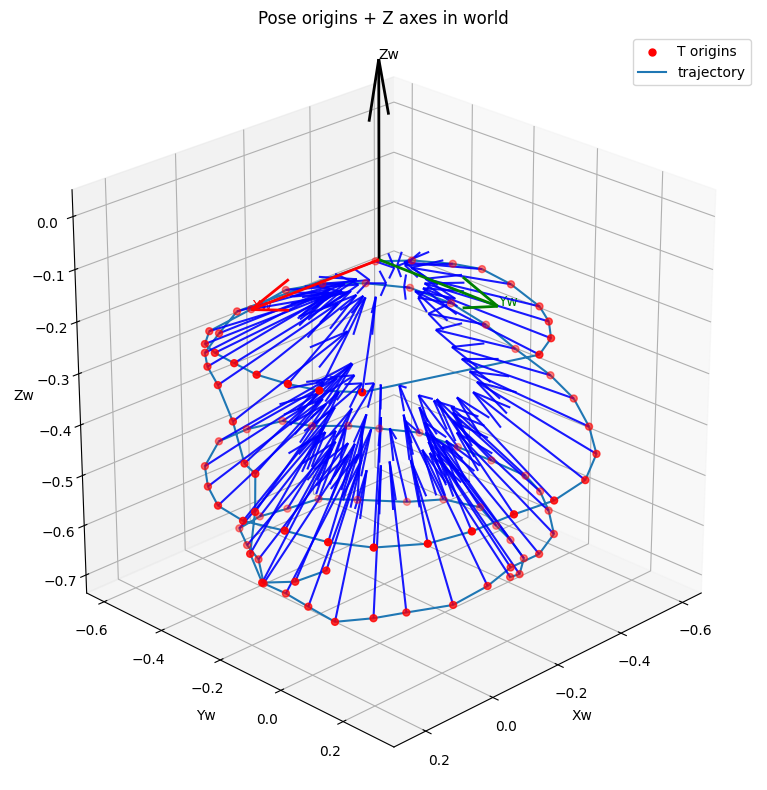

In [6]:
%matplotlib inline
from matplotlib import pyplot as plt
plot_T_origins_and_world_z(Ts)

In [5]:
def normalizeH(H, K):
    return np.linalg.inv(K)@H@K
normalizeH(Hs[0], K)

array([[ 0.64206235,  0.43271942,  0.03944543],
       [-0.34449804,  0.50041664,  0.37219531],
       [ 0.27054404, -0.41571425,  0.84837444]])

In [32]:
def plane_eqn_from_homography_pose(H, K, T, eps=1e-9):
    H = np.linalg.inv(H)
    Hn = normalizeH(H, K)
    R = T[:3, :3]
    M = Hn - R
    t = T[:3, 3:4]
    denom = float((t.T@t)[0, 0])
    if denom < eps:
        print("Zero Translation !!")
        raise ValueError("Zeros Translation")
    wT = (t.T @ M)/denom
    w = wT.reshape(3)
    nw = np.linalg.norm(w)
    if nw < eps:
        raise ValueError("Degen Plane !")
    n = w / nw
    d = 1.0 / nw

    if d < 0:
        n = -n
        d = -d
    return np.hstack([n ,d ])
    
def rel_pose_c0_to_c1(T_c0_w, T_c1_w):
    # T_10 = T_c1_w * T_w_c0
    T_w_c0 = invert_T(T_c0_w)
    return T_c1_w @ T_w_c0
    
def project(K, X):
    # X: (N,3) in camera coords
    x = (K @ X.T).T
    return x[:, :2] / x[:, 2:3]

def apply_H(H, x0):
    # x0: (N,2) pixels in img0
    x0_h = cv2.convertPointsToHomogeneous(x0).reshape(-1,3)
    y = (H @ x0_h.T).T
    return y[:, :2] / y[:, 2:3]

In [34]:
def rel_pose_c0_to_c1(T_c0_w, T_c1_w):
    # T_10 = T_c1_w * T_w_c0
    T_w_c0 = invert_T(T_c0_w)
    return T_c1_w @ T_w_c0
def skew(t):
    t = np.asarray(t, np.float64).reshape(3)
    tx, ty, tz = t
    return np.array([[0, -tz, ty],
                     [tz, 0, -tx],
                     [-ty, tx, 0]], dtype=np.float64)

def getEfromTs(T0, T1):
    T_rel = rel_pose_c0_to_c1(T0, T1)
    t = T_rel[:3, 3]
    R = T_rel[:3, :3]
    return skew(t)@R
def getF(E, K):
    return np.linalg.inv(K).T@E@np.linalg.inv(K)
    

In [35]:
def getEpFromF(F, eps=1e-12):
    # e  : null(F)    in image 0
    # e' : null(F^T)  in image 1
    U, S, Vt = np.linalg.svd(F)
    e  = Vt[-1, :]          # nullspace of F
    U2, S2, Vt2 = np.linalg.svd(F.T)
    ep = Vt2[-1, :]         # nullspace of F^T

    # normalize to inhomogeneous if possible
    def norm_h(x):
        if abs(x[2]) > eps:
            return x / x[2]
        return x
    return norm_h(e), norm_h(ep)


In [36]:
E = getEfromTs(Ts[0], Ts[1])
F = getF(E, K)
e0, e1 = getEpFromF(F)
print(f"e0 {e0} e1 {e1}")

e0 [ 7.27230279e+03 -7.18038836e+03  1.00000000e+00] e1 [ 8.29139029e+03 -6.54659084e+03  1.00000000e+00]


In [37]:
print("||F e||:", np.linalg.norm(F @ e0))
print("||F^T e'||:", np.linalg.norm(F.T @ e1))


||F e||: 2.828293239870371e-16
||F^T e'||: 1.2383128026826036e-16


In [39]:
def _normalize(v, eps=1e-12):
    n = np.linalg.norm(v)
    if n < eps:
        raise ValueError("Zero-norm vector.")
    return v / n

def _plane_basis_from_normal(n_w):
    """
    Build orthonormal basis (b1, b2) spanning plane with normal n_w (unit).
    """
    n_w = _normalize(n_w)
    # pick a reference axis not parallel to n
    ref = np.array([1.0, 0.0, 0.0], dtype=np.float64)
    if abs(n_w @ ref) > 0.9:
        ref = np.array([0.0, 1.0, 0.0], dtype=np.float64)
    b1 = _normalize(np.cross(n_w, ref))
    b2 = _normalize(np.cross(n_w, b1))
    return b1, b2

def getHomography(n_w, d_w, T_c_w, K, eps=1e-12):
    """
    Compute homography mapping IMAGE PIXELS -> PLANE COORDS (u,v) for world plane n_w^T X_w = d_w.

    Inputs
    ------
    n_w : (3,) plane normal in WORLD coordinates (need not be unit)
    d_w : scalar plane offset in WORLD coordinates
          Plane is {X_w | n_w^T X_w = d_w}
    T_w_c : (4,4) camera pose as world-from-camera (c2w):
            X_w = R_wc X_c + t_wc
    K : (3,3) camera intrinsics

    Returns
    -------
    H_img2plane : (3,3) homography mapping pixel x ~ [u,v,1] (inhom after divide)
                  such that [u,v,1]^T ~ H_img2plane [x,y,1]^T
    H_plane2img : (3,3) inverse mapping plane->image
    meta : dict with plane frame {p0,b1,b2} in world coords
    """
    n_w = np.asarray(n_w, dtype=np.float64).reshape(3)
    d_w = float(d_w)
    K = np.asarray(K, dtype=np.float64).reshape(3, 3)
    R_cw = T_c_w[:3, :3]
    t_cw = T_c_w[:3, 3]
    # Normalize plane normal (keep the same plane)
    nn = np.linalg.norm(n_w)
    if nn < eps:
        raise ValueError("Degenerate plane normal.")
    n_u = n_w / nn
    d_u = d_w / nn  # so that n_u^T X = d_u

    # Choose plane origin p0 = closest point on plane to world origin
    # For unit normal: p0 = d * n
    p0 = d_u * n_u  # (3,)

    # Orthonormal basis on the plane
    b1, b2 = _plane_basis_from_normal(n_u)



    # Homography plane->image:
    # X_w(u,v) = p0 + b1 u + b2 v
    # X_c = R_cw X_w + t_cw = R_cw[b1 b2 p0] [u v 1]^T + t_cw
    # => x ~ K [ R_cw b1, R_cw b2, R_cw p0 + t_cw ] [u v 1]^T
    H_plane2img = K @ np.column_stack([R_cw @ b1, R_cw @ b2, (R_cw @ p0 + t_cw)])

    # Image->plane
    H_img2plane = np.linalg.inv(H_plane2img)

    meta = {
        "p0_w": p0,   # origin of plane coords in world
        "b1_w": b1,   # u-axis in world
        "b2_w": b2,   # v-axis in world
        "n_w_unit": n_u,
        "d_w_unit": d_u,
    }
    return H_img2plane, H_plane2img, meta

In [191]:
H0, H0inv, _ = getHomography(np.array([0, 1, 0]), -0.381, np.linalg.inv(Ts[0]), K)
H1, H1inv, _ = getHomography(np.array([0, 1, 0]), -0.381, np.linalg.inv(Ts[1]), K)

In [192]:
def _apply_H(H, pts):
    """pts: (N,2) -> (N,2)"""
    pts = np.asarray(pts, np.float64).reshape(-1, 1, 2)
    q = cv2.perspectiveTransform(pts, np.asarray(H, np.float64))
    return q.reshape(-1, 2)

def filter_correspondences_by_plane_H(
    pts0, pts1,
    H_10,
    eprime=None,                 # epipole in image1 (2,) or (3,), optional
    thresh_px=3.0,               # pixel residual threshold
    use_symmetric=True,          # symmetric transfer error (recommended)
    epipolar_angle_deg=25.0,     # if eprime provided
):
    """
    Keeps correspondences (pts0[i] <-> pts1[i]) that are consistent with plane-induced homography H_10.

    Returns:
      keep_mask: (N,) bool
      err: (N,) symmetric or forward transfer error in pixels
      res: (N,2) residual in image1: pts1 - H(pts0)
    """
    pts0 = np.asarray(pts0, np.float64).reshape(-1, 2)
    pts1 = np.asarray(pts1, np.float64).reshape(-1, 2)
    H = np.asarray(H_10, np.float64)

    pts1_hat = apply_H(H, pts0)
    res_fwd = pts1 - pts1_hat
    err_fwd = np.linalg.norm(res_fwd, axis=1)

    if use_symmetric:
        Hinv = np.linalg.inv(H)
        pts0_hat = apply_H(Hinv, pts1)
        err_bwd = np.linalg.norm(pts0 - pts0_hat, axis=1)
        err = np.sqrt(err_fwd**2 + err_bwd**2)
    else:
        err = err_fwd

    keep = err < float(thresh_px)

    # Optional: residual direction should align with epipolar direction to e'
    if eprime is not None:
        eprime = np.asarray(eprime, np.float64).reshape(-1)
        if eprime.size == 3 and abs(eprime[2]) > 1e-12:
            eprime = eprime[:2] / eprime[2]
        else:
            eprime = eprime[:2]

        epi_dir = eprime.reshape(1, 2) - pts1_hat
        epi_dir /= (np.linalg.norm(epi_dir, axis=1, keepdims=True) + 1e-12)

        res_u = res_fwd / (np.linalg.norm(res_fwd, axis=1, keepdims=True) + 1e-12)
        cosang = np.sum(res_u * epi_dir, axis=1)
        cosang = np.clip(cosang, -1.0, 1.0)
        ang = np.degrees(np.arccos(cosang))
        keep = keep & (ang < float(epipolar_angle_deg))

    return keep, err, res_fwd

In [193]:
from vismatch import get_matcher
from vismatch.viz import plot_matches

matcher = get_matcher("romav2", device="cuda")

Using cache found in /home/r4hul/.cache/torch/hub/facebookresearch_dinov3_adc254450203739c8149213a7a69d8d905b4fcfa


2026-02-06 14:28:28 INFO     romav2.romav2 - romav2:116 in __init__ - RoMa v2 initialized.

In [194]:
img_size = 1024
img0 = matcher.load_image(obj_file["good_imgs"][0])
img1 = matcher.load_image(obj_file["good_imgs"][1])

In [195]:
result = matcher(img0, img1)

array([<Axes: >, <Axes: >], dtype=object)

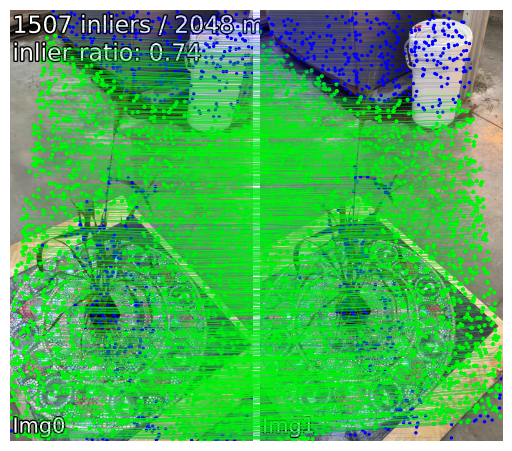

In [196]:
plot_matches(img0, img1, result, save_path="plot_matches.png")

In [197]:
keep, err, res_fwd = filter_correspondences_by_plane_H(result['matched_kpts0'], result['matched_kpts0'], H1@H0inv, e1)

In [198]:
pts_h = cv2.convertPointsToHomogeneous(result['matched_kpts0']).reshape(-1, 3)
H_10 =  H1@H0inv
wrapped = H_10@pts_h.T
wrapped = wrapped/wrapped[2, :]
delta_wraps = np.linalg.norm(wrapped - e1.reshape(3, 1), axis=0)
delta_matches = np.linalg.norm(cv2.convertPointsToHomogeneous(result['matched_kpts1']).reshape(-1, 3).T - e1.reshape(-1, 1), axis=0)

In [199]:
keep = delta_wraps < delta_matches

In [200]:
#keep = np.linalg.norm(pts_hat, axis=0)<200

In [201]:
m0 = result['matched_kpts0'][~keep, :]
m1 = result['matched_kpts1'][~keep, :]

In [202]:
def plot_matched_keypoints(
    img1,
    img2,
    kpts1,
    kpts2,
    matches=None,
    inlier_mask=None,
    max_matches=None,
    figsize=(12, 6),
    line_width=0.8,
):
    """
    Plot two images side-by-side with matched keypoints.

    Args:
        img1, img2:
            Input images (BGR or RGB), shape (H, W, 3) or (H, W)

        kpts1, kpts2:
            Keypoints as:
              - (N, 2) arrays of (x, y), OR
              - list[cv2.KeyPoint]

        matches:
            Optional list of cv2.DMatch. If None, assumes kpts1[i] <-> kpts2[i].

        inlier_mask:
            Optional boolean or {0,1} array (len == #matches). Used to highlight inliers.

        max_matches:
            Optional int to subsample matches for visualization.

        figsize:
            Matplotlib figure size.

    """

    # ---- convert to RGB for matplotlib
    def to_rgb(img):
        if img.ndim == 2:
            return np.stack([img] * 3, axis=-1)
        if img.shape[2] == 3:
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return img

    img1 = to_rgb(img1)
    img2 = to_rgb(img2)

    # ---- extract (x,y) from cv2.KeyPoint if needed
    def kpts_to_xy(kpts):
        if isinstance(kpts[0], cv2.KeyPoint):
            return np.array([kp.pt for kp in kpts], dtype=np.float32)
        return np.asarray(kpts, dtype=np.float32)

    pts1 = kpts_to_xy(kpts1)
    pts2 = kpts_to_xy(kpts2)

    # ---- build correspondence indices
    if matches is None:
        assert len(pts1) == len(pts2), "kpts must be same length if matches=None"
        idx1 = np.arange(len(pts1))
        idx2 = np.arange(len(pts2))
    else:
        if max_matches is not None:
            matches = matches[:max_matches]
        idx1 = np.array([m.queryIdx for m in matches])
        idx2 = np.array([m.trainIdx for m in matches])

    pts1 = pts1[idx1]
    pts2 = pts2[idx2]

    if inlier_mask is not None:
        inlier_mask = np.asarray(inlier_mask).astype(bool)

    # ---- create canvas
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    H = max(h1, h2)
    W = w1 + w2

    canvas = np.zeros((H, W, 3), dtype=np.uint8)
    canvas[:h1, :w1] = img1
    canvas[:h2, w1:w1 + w2] = img2

    # ---- plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(canvas)
    ax.axis("off")

    for i, (p1, p2) in enumerate(zip(pts1, pts2)):
        x1, y1 = p1
        x2, y2 = p2
        x2 += w1  # shift right image

        if inlier_mask is None:
            color = "yellow"
        else:
            color = "lime" if inlier_mask[i] else "red"

        ax.plot([x1, x2], [y1, y2], color=color, linewidth=line_width)
        ax.scatter([x1, x2], [y1, y2], c=color, s=10)

    plt.tight_layout()
    plt.show()

In [203]:
keep

array([False,  True, False, ...,  True, False,  True])

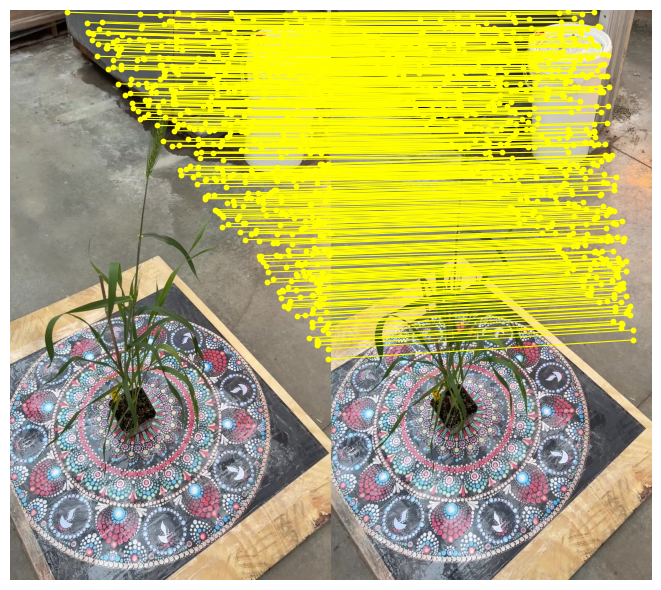

In [204]:
plot_matched_keypoints(imgs[0], imgs[1], m0, m1)

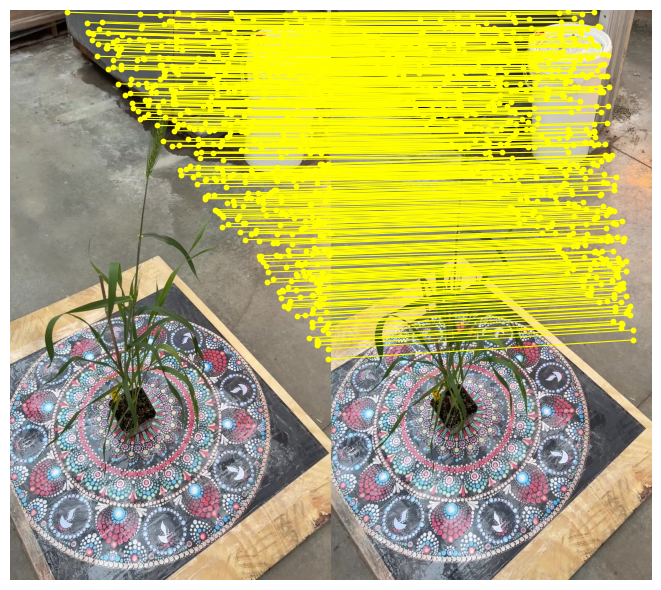

In [205]:
plot_matched_keypoints(imgs[0], imgs[1], m0, m1)

In [291]:
def draw_line(K, T, line_xy_plane, img, color=(0, 255, 0), thickness=2, span=20.0):
    """
    Draws a WORLD xy-plane line (z=0) onto the image.

    Line in world (xy plane):
        a*x + b*y + d = 0     (z is implicitly 0)

    Args:
        K: (3,3) intrinsics
        T: (4,4) camera->world transform (T_cw)
        line_xy_plane: [a, b, d]
        img: BGR image
        span: how far (in world units) to pick endpoints around the camera position

    Returns:
        img_out: image with the projected line drawn
    """
    img_out = img.copy()
    K = np.asarray(K, dtype=np.float64)
    T = np.asarray(T, dtype=np.float64)
    a, b, d = [float(v) for v in line_xy_plane]

    # ---- Convert T_cw (camera->world) into world->camera (R_wc, t_wc) for OpenCV projection
    R_cw = T[:3, :3]
    t_cw = T[:3, 3].reshape(3, 1)

    R_wc = R_cw.T
    t_wc = -R_wc @ t_cw  # so that p_c = R_wc * p_w + t_wc

    rvec, _ = cv2.Rodrigues(R_wc)
    tvec = t_wc

    # ---- Choose two far-apart points on the line in WORLD coords (z=0), near camera xy
    cam_x = float(t_cw[0])
    cam_y = float(t_cw[1])

    if abs(b) > abs(a):
        # parameterize by x
        x1 = cam_x - span
        x2 = cam_x + span
        if abs(b) < 1e-12:
            return img_out
        y1 = (-d - a * x1) / b
        y2 = (-d - a * x2) / b
        P_w = np.array([[x1, y1, 0.0],
                        [x2, y2, 0.0]], dtype=np.float64)
    else:
        # parameterize by y
        y1 = cam_y - span
        y2 = cam_y + span
        if abs(a) < 1e-12:
            return img_out
        x1 = (-d - b * y1) / a
        x2 = (-d - b * y2) / a
        P_w = np.array([[x1, y1, 0.0],
                        [x2, y2, 0.0]], dtype=np.float64)

    # ---- Project to pixels
    print(P_w)
    dist = np.zeros((5, 1), dtype=np.float64)  # assume already-undistorted; change if you have distortion
    uv, _ = cv2.projectPoints(P_w, rvec, tvec, K, dist)  # (2,1,2)
    uv = uv.reshape(-1, 2)

    pt1 = (int(round(uv[0, 0])), int(round(uv[0, 1])))
    pt2 = (int(round(uv[1, 0])), int(round(uv[1, 1])))
    print(pt1)
    print(pt2)
    # ---- Clip to image and draw
    H, W = img_out.shape[:2]
    ok, pt1c, pt2c = cv2.clipLine((0, 0, W, H), pt1, pt2)
    if ok:
        cv2.line(img_out, pt1c, pt2c, color, thickness, lineType=cv2.LINE_AA)
    P_w = np.zeros((3, 1))
    uv_org, _ = cv2.projectPoints(P_w, rvec, tvec, K, dist)
    uv_org = uv_org.reshape(2)
    center = (int(round(uv_org[0])), int(round(uv_org[1])))
    img_out = cv2.circle(img_out, center, 500, (255, 255, 255))
    return img_out

In [292]:
img_out = draw_line(K, Ts[0], [1, 0, -0.381], imgs[0], thickness=10, span=1)

[[ 0.381     -0.9095012  0.       ]
 [ 0.381      1.0904988  0.       ]]
(571, 268)
(8293, 6095)


/tmp/ipykernel_522214/3478297069.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cam_x = float(t_cw[0])
/tmp/ipykernel_522214/3478297069.py:35: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cam_y = float(t_cw[1])


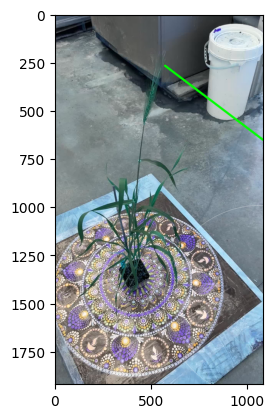

In [293]:
plt.imshow(img_out)